In [1]:
import pandas as pd
import glob
import os
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy
import albumentations as A
from albumentations.pytorch import ToTensorV2

from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from collections import Counter
from torchvision import transforms as T
from torch.utils.data import DataLoader

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score, f1_score

INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.4 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


In [2]:
%env CUDA_VISIBLE_DEVICES=0
DATASET = "/home/anmilka/different/confirmed_fronts/"
COLOR_THRESHOLD = 200
ITEM_THRESHOLD = 1000

env: CUDA_VISIBLE_DEVICES=0


### Подготовка данных

In [3]:
paths = []
colors = []

for img_path in glob.glob(f"{DATASET}/*/*/*.jpg"):
    try:
        im = Image.open(img_path)
    except:
        print(img_path)
        continue

    color = Path(img_path).stem.split("$$")[3]

    if color == 'Unlisted':
        continue

    paths.append(img_path)
    colors.append(color)

counter = Counter(colors)
print(counter)

Counter({'Black': 14317, 'Grey': 9474, 'White': 9395, 'Blue': 8483, 'Silver': 7770, 'Red': 6095, 'Brown': 911, 'Green': 777, 'Yellow': 667, 'Beige': 600, 'Orange': 559, 'Purple': 362, 'Bronze': 329, 'Gold': 217, 'Multicolour': 196, 'Pink': 87, 'Turquoise': 26, 'Maroon': 26, 'Burgundy': 9, 'Magenta': 9, 'Indigo': 1, 'Navy': 1})


In [4]:
colors_to_keep = sorted([k for k, v in counter.items() if v >= COLOR_THRESHOLD])
print(colors_to_keep)

NUM_CLASSES = len(colors_to_keep)
def get_name_by_ind(ind):
    return colors_to_keep[ind]

['Beige', 'Black', 'Blue', 'Bronze', 'Brown', 'Gold', 'Green', 'Grey', 'Orange', 'Purple', 'Red', 'Silver', 'White', 'Yellow']


In [5]:
items_to_keep = {path: color for path, color in zip(paths, colors) if color in colors_to_keep}
paths_to_keep = [[p] for p in items_to_keep.keys()]
labels = []

for path, color in items_to_keep.items():
    color_id = colors_to_keep.index(color)
    labels.append(color_id)

print(len(paths_to_keep), len(labels))
counter = Counter(labels)
print(counter)
print("Num classes:", NUM_CLASSES)

59956 59956
Counter({1: 14317, 7: 9474, 12: 9395, 2: 8483, 11: 7770, 10: 6095, 4: 911, 6: 777, 13: 667, 0: 600, 8: 559, 9: 362, 3: 329, 5: 217})
Num classes: 14


In [6]:
train_paths, test_paths, train_labels, test_labels = train_test_split(paths_to_keep, labels, shuffle=True, test_size=0.05, random_state=25)
print(len(train_paths), len(train_labels), len(set(train_labels)))
print(len(test_paths), len(test_labels), len(set(test_labels)))

56958 56958 14
2998 2998 14


In [7]:
counter = Counter(train_labels)
print(len(train_labels), counter)

train_labels_arr = np.asarray(train_labels)
train_paths_arr = np.asarray(train_paths)

extended_train_paths = deepcopy(train_paths)
extended_train_labels = deepcopy(train_labels)

for class_id, items_count in counter.items():
    if items_count < ITEM_THRESHOLD:
        class_indices = np.where(train_labels_arr == class_id)[0]
        class_train_paths = train_paths_arr[class_indices]
        class_train_labels = train_labels_arr[class_indices]

        coef = ITEM_THRESHOLD // len(class_indices)
        coef = coef if float(ITEM_THRESHOLD-len(class_indices))/(ITEM_THRESHOLD) > 0.2 else coef -1

        duplicates_class_train_paths = list(class_train_paths) * coef
        duplicates_class_train_labels = list(class_train_labels) * coef

        extended_train_paths.extend(duplicates_class_train_paths)
        extended_train_labels.extend(duplicates_class_train_labels)

counter = Counter(extended_train_labels)
print(len(extended_train_labels), counter)

56958 Counter({1: 13611, 7: 9030, 12: 8913, 2: 8034, 11: 7390, 10: 5764, 4: 864, 6: 741, 13: 641, 0: 571, 8: 537, 9: 352, 3: 306, 5: 204})
61886 Counter({1: 13611, 7: 9030, 12: 8913, 2: 8034, 11: 7390, 10: 5764, 6: 1482, 13: 1282, 3: 1224, 0: 1142, 8: 1074, 9: 1056, 5: 1020, 4: 864})


In [8]:
class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform):
        # self.images = []
        # for path in paths:
        #     img = Image.open(path[0])
        #     self.images.append(img)

        self.labels = labels
        self.transform = transform
        self.paths = paths

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        label = self.labels[index]
        try:
            image = Image.open(self.paths[index][0])
        except:
            print("error in open", self.paths[index][0])

        try:
            image_tensor = self.transform(image=np.asarray(image))["image"]
        except Exception as e:
            print("error in transform", self.paths[index][0], e)
            return

        return image_tensor, label

In [9]:
img_sz = 256
crop_sz = 224

train_data_transforms = A.Compose([
    A.Resize(img_sz, img_sz),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(p=0.3, hue=0.0),
    A.Affine(p=0.5),
    A.OpticalDistortion(distort_limit=0.1, shift_limit=0.1, p=0.5),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
    A.RandomCrop(crop_sz, crop_sz),
    A.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Определение трансформаций для тестовых данных
test_data_transforms = A.Compose([
    A.Resize(img_sz, img_sz),
    A.CenterCrop(crop_sz, crop_sz),
    A.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ToTensorV2()
])

/home/anmilka/miniconda3/envs/common_latest_libs/lib/python3.10/site-packages/pydantic/main.py:426: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue: Expected `float` but got `list` with value `[0.0, 0.0]` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `tuple[float, float]` but got `list` with value `[0.0, 0.0]` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


In [10]:
train_dataset = ImageDataset(paths=extended_train_paths,
                            labels=extended_train_labels,
                            transform=train_data_transforms)
                            
test_dataset = ImageDataset(paths=test_paths,
                            labels=test_labels,
                            transform=test_data_transforms)

print(len(train_dataset), len(test_dataset))

61886 2998


In [11]:
batch_size = 512
num_workers = 8

train_loader = DataLoader(train_dataset,
                            batch_size=batch_size,
                            shuffle=True,
                            num_workers=num_workers,
                            pin_memory=True,
                            drop_last = True)

val_loader = DataLoader(test_dataset,
                            batch_size=batch_size,
                            shuffle=False,
                            num_workers=num_workers,
                            pin_memory=True)

In [12]:
def plot_training_metrics(metrics):
    fig, axs = plt.subplots(1, 4, figsize=(28, 7))

    plt.subplot(1, 4, 1)
    plt.plot(np.arange(len(metrics["train_losses"])), metrics["train_losses"])
    plt.title('Train Loss')
    plt.xlabel('Step')

    plt.subplot(1, 4, 2)
    plt.plot(np.arange(len(metrics["val_losses"])), metrics["val_losses"])
    plt.title('Val Loss')
    plt.xlabel('Epoch')

    plt.subplot(1, 4, 3)
    plt.plot(np.arange(len(metrics["train_f1_macros"])), metrics["train_f1_macros"], label='Train F1_macro')
    plt.plot(np.arange(len(metrics["train_accuracies"])), metrics["train_accuracies"], label='Train Accuracy')
    plt.title('Train Metrics')
    plt.xlabel('Step')
    plt.legend()

    plt.subplot(1, 4, 4)
    plt.plot(np.arange(len(metrics["val_f1_macros"])), metrics["val_f1_macros"], label='Val F1_macro')
    plt.plot(np.arange(len(metrics["val_accuracies"])), metrics["val_accuracies"], label='Val Accuracy')
    plt.title('Val Metrics')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

    

def print_score_per_class(score):
    precision, recall, fscore, support = score

    try:
        from prettytable import PrettyTable
        table = PrettyTable()
        table.add_column("Class", [get_name_by_ind(i) for i in range(NUM_CLASSES)])
        table.add_column("Precision", [round(el, 4) for el in precision])
        table.add_column("Recall", [round(el, 4) for el in recall])
        table.add_column("F1", [round(el, 4) for el in fscore])
        table.add_column("Support", support)
    except:
        return

    print(table)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=25, log_steps=20):
    model.to(device)
    metrics = {}

    metrics["train_losses"] = []
    metrics["train_accuracies"] = []
    metrics["train_f1_macros"] = []
    metrics["train_scores"] = []

    metrics["val_losses"] = []
    metrics["val_accuracies"] = []
    metrics["val_f1_macros"] = []
    metrics["val_scores"] = []

    step = 0

    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            if step % log_steps == 0:
                _, preds = torch.max(outputs, 1)
                preds = preds.cpu().numpy()
                labels = labels.cpu().numpy()

                metrics["train_losses"].append(loss.item())
                
                accuracy = accuracy_score(labels, preds)
                metrics["train_accuracies"].append(accuracy)

                f1_macro = f1_score(labels, preds, average='macro')
                metrics["train_f1_macros"].append(f1_macro)

                # if (len(set(labels))) == NUM_CLASSES:
                #     score = precision_recall_fscore_support(labels, preds, zero_division=0.0)
                #     print_score_per_class(score)
                #     metrics["train_scores"].append(score)

                print(f'Epoch {epoch}/{num_epochs - 1}, Step {step}, Train Loss: {metrics["train_losses"][-1]:.4f}')

            loss.backward()
            optimizer.step()
            step +=1

        scheduler.step()

        # Validation phase
        model.eval()
        val_running_loss = 0.0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(val_loader.dataset)
        metrics["val_losses"].append(val_loss)
        
        accuracy = accuracy_score(all_labels, all_preds)
        metrics["val_accuracies"].append(accuracy)

        f1_macro = f1_score(all_labels, all_preds, average='macro')
        metrics["val_f1_macros"].append(f1_macro)

        score = precision_recall_fscore_support(all_labels, all_preds, zero_division=0.0)
        print_score_per_class(score)

        print(f'Epoch {epoch}/{num_epochs - 1}, Val Loss: {val_loss:.4f}, Val Acc: {accuracy:.4f}, Val F1_macro: {f1_macro:.4f}')
        metrics["val_scores"].append(score)

        if f1_macro > 0.8:
            return model, metrics


    return model, metrics

### ResNet-34 (моя имплементация)

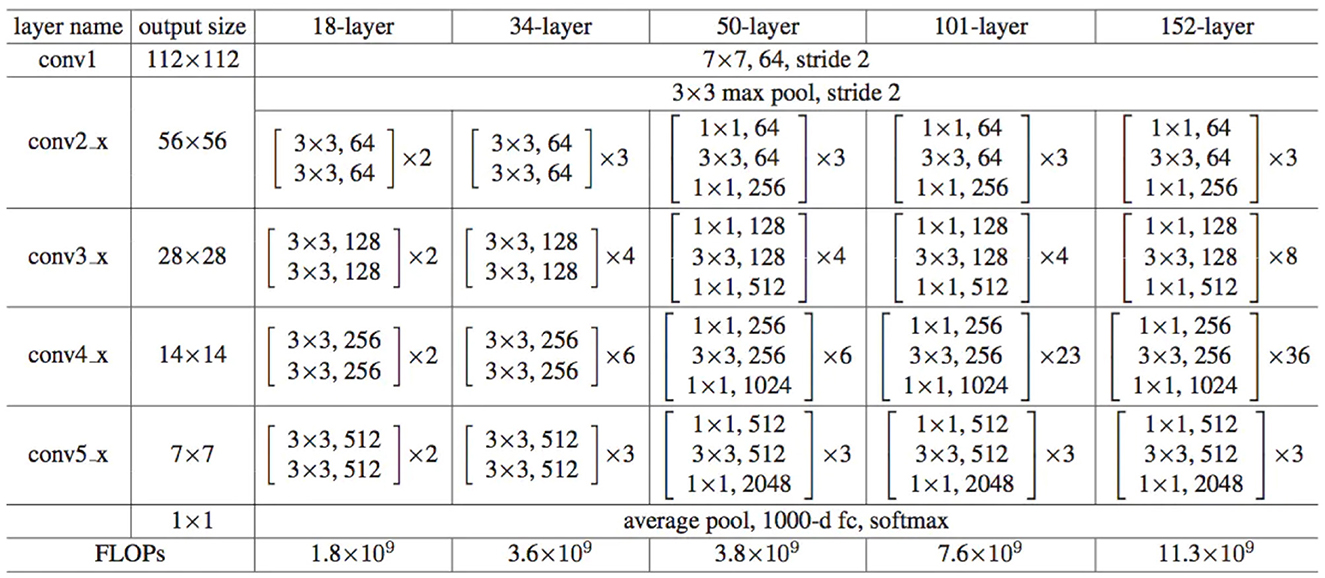

In [13]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

class ResNet34(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Стек слоев ResNet
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [14]:
model = ResNet34(BasicBlock, [3, 4, 6, 3], NUM_CLASSES)
print(model)

ResNet34(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)


In [15]:
model = ResNet34(BasicBlock, [3, 4, 6, 3], NUM_CLASSES)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 50], gamma=0.1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

trained_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=80)

Epoch 0/79, Step 0, Train Loss: 2.6577
Epoch 0/79, Step 20, Train Loss: 1.4958
Epoch 0/79, Step 40, Train Loss: 1.1700
Epoch 0/79, Step 60, Train Loss: 1.1813
Epoch 0/79, Step 80, Train Loss: 1.1493
Epoch 0/79, Step 100, Train Loss: 1.0646
+--------+-----------+--------+--------+---------+
| Class  | Precision | Recall |   F1   | Support |
+--------+-----------+--------+--------+---------+
| Beige  |   0.022   | 0.069  | 0.0333 |    29   |
| Black  |   0.5506  | 0.932  | 0.6923 |   706   |
|  Blue  |   0.8224  | 0.5568 | 0.664  |   449   |
| Bronze |    0.05   | 0.0435 | 0.0465 |    23   |
| Brown  |    0.0    |  0.0   |  0.0   |    47   |
|  Gold  |   0.0896  | 0.4615 |  0.15  |    13   |
| Green  |   0.1037  | 0.3889 | 0.1637 |    36   |
|  Grey  |   0.576   | 0.2815 | 0.3782 |   444   |
| Orange |   0.3846  | 0.2273 | 0.2857 |    22   |
| Purple |   0.0588  |  0.1   | 0.0741 |    10   |
|  Red   |   0.9099  | 0.9758 | 0.9417 |   331   |
| Silver |   0.6684  | 0.3447 | 0.4549 |   380

In [16]:
plot_training_metrics(metrics)

### Pretrained ResNet-34 from torchvision

In [17]:
from torchvision.models import resnet34

model = resnet34(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, NUM_CLASSES)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 50], gamma=0.1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

trained_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=80)

Epoch 0/79, Step 0, Train Loss: 2.8539
Epoch 0/79, Step 20, Train Loss: 0.5939
Epoch 0/79, Step 40, Train Loss: 0.5635
Epoch 0/79, Step 60, Train Loss: 0.4545
Epoch 0/79, Step 80, Train Loss: 0.5223
Epoch 0/79, Step 100, Train Loss: 0.4923
+--------+-----------+--------+--------+---------+
| Class  | Precision | Recall |   F1   | Support |
+--------+-----------+--------+--------+---------+
| Beige  |   0.3205  | 0.8621 | 0.4673 |    29   |
| Black  |   0.9165  | 0.8244 | 0.868  |   706   |
|  Blue  |   0.8983  | 0.8463 | 0.8716 |   449   |
| Bronze |    0.6    | 0.5217 | 0.5581 |    23   |
| Brown  |    0.0    |  0.0   |  0.0   |    47   |
|  Gold  |   0.4545  | 0.3846 | 0.4167 |    13   |
| Green  |   0.8966  | 0.7222 |  0.8   |    36   |
|  Grey  |   0.6971  | 0.6014 | 0.6457 |   444   |
| Orange |   0.4839  | 0.6818 | 0.566  |    22   |
| Purple |   0.7143  |  0.5   | 0.5882 |    10   |
|  Red   |   0.9813  | 0.9517 | 0.9663 |   331   |
| Silver |   0.6488  | 0.9237 | 0.7622 |   380

In [19]:
plot_training_metrics(metrics)

### Pretrained ViT from torchvision

In [20]:
from torchvision.models.vision_transformer import vit_b_16
from torchvision.models import ViT_B_16_Weights

model = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
model.heads.head = nn.Linear(768, NUM_CLASSES)
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [21]:
batch_size = 128
num_workers = 8

train_loader = DataLoader(train_dataset,
                            batch_size=batch_size,
                            shuffle=True,
                            num_workers=num_workers,
                            pin_memory=True,
                            drop_last = True)

val_loader = DataLoader(test_dataset,
                            batch_size=batch_size,
                            shuffle=False,
                            num_workers=num_workers,
                            pin_memory=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.00005)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10], gamma=0.1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=20)

Epoch 0/19, Step 0, Train Loss: 2.8712
Epoch 0/19, Step 20, Train Loss: 0.9690
Epoch 0/19, Step 40, Train Loss: 0.9312
Epoch 0/19, Step 60, Train Loss: 0.6873
Epoch 0/19, Step 80, Train Loss: 0.5718
Epoch 0/19, Step 100, Train Loss: 0.5130
Epoch 0/19, Step 120, Train Loss: 0.4206
Epoch 0/19, Step 140, Train Loss: 0.4800
Epoch 0/19, Step 160, Train Loss: 0.4817
Epoch 0/19, Step 180, Train Loss: 0.4628
Epoch 0/19, Step 200, Train Loss: 0.6493
Epoch 0/19, Step 220, Train Loss: 0.4749
Epoch 0/19, Step 240, Train Loss: 0.3004
Epoch 0/19, Step 260, Train Loss: 0.4044
Epoch 0/19, Step 280, Train Loss: 0.4428
Epoch 0/19, Step 300, Train Loss: 0.4588
Epoch 0/19, Step 320, Train Loss: 0.3233
Epoch 0/19, Step 340, Train Loss: 0.3875
Epoch 0/19, Step 360, Train Loss: 0.5112
Epoch 0/19, Step 380, Train Loss: 0.3647
Epoch 0/19, Step 400, Train Loss: 0.3537
Epoch 0/19, Step 420, Train Loss: 0.3101
Epoch 0/19, Step 440, Train Loss: 0.2936
Epoch 0/19, Step 460, Train Loss: 0.4052
Epoch 0/19, Step 480, 

In [22]:
plot_training_metrics(metrics)

#### Визуализация аугментаций

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt

# Задание параметров для изображений
img_sz = 256
crop_sz = 224

# Определение трансформаций для обучающих данных
train_data_transforms = A.Compose([
    A.Resize(img_sz, img_sz),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(p=1, hue=0.0),
    A.Affine(p=0.5),
    A.OpticalDistortion(distort_limit=0.1, shift_limit=0.1, p=0.5),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
    A.CenterCrop(crop_sz, crop_sz),
    A.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ToTensorV2()
])

# Определение трансформаций для тестовых данных
test_data_transforms = A.Compose([
    A.Resize(img_sz, img_sz),
    A.CenterCrop(crop_sz, crop_sz),
    A.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ToTensorV2()
])

# Функция для визуализации аугментаций
def visualize_augmentations(image, transform, num_examples=5):
    fig, axes = plt.subplots(1, num_examples, figsize=(15, 5))

    for i in range(num_examples):
        augmented = transform(image=image)
        img_aug = augmented["image"].permute(1, 2, 0).cpu().numpy()  # Изменение порядка каналов для визуализации

        axes[i].imshow((img_aug * 0.5) + 0.5)  # Обратное преобразование нормализации
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()



for i, img_path in enumerate(glob.glob(f"{DATASET}/*/*/*.jpg")):
    im = Image.open(img_path)
    visualize_augmentations(np.asarray(im), train_data_transforms)
    if i ==10:
        break



/home/anmilka/miniconda3/envs/common_latest_libs/lib/python3.10/site-packages/pydantic/main.py:426: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue: Expected `float` but got `list` with value `[0.0, 0.0]` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `tuple[float, float]` but got `list` with value `[0.0, 0.0]` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
